# Exploratory analysis
In this notebook we'll do exploratory analysis of the New York Times Bestseller list data, focusing on the authors who had the most titles ranked #1 in the Fiction categories of the New York Times Bestseller list between 2010-2025, and the publishing groups and their imprints who had titles on #1 spot the most on said period. 

## Libraries

In [72]:
"""Here we import the libraries necessary for our EDA process"""
import pandas as pd
import sqlite3
import seaborn as sns
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

## Load the data

In [2]:
df = pd.read_csv('nyt_bestsellers_final.csv')

C:\Users\jbigu\AppData\Local\Temp\ipykernel_14184\844195986.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('nyt_bestsellers_final.csv')


In [3]:
# Create the db connection
conn = sqlite3.connect('nyt.db')
df.to_sql('bestsellers', conn, if_exists='replace', index=False)

328049

## Exploratory Data Analysis

In [4]:
# A list of all the Fiction categories (no format
# combination, nor comics/manga/graphic novels), this will later 
# be used to select each category in our data.
lists = [
    "Hardcover Fiction",
    "Paperback Trade Fiction",
    "Paperback Mass-Market Fiction",
    "E-Book Fiction",
    "Audio Fiction"
]

### Authors who got to rank 1 in 2010-2025 (Fiction)
In this section we'll obtain all of the titles that got rank #1 between 2010-2025 in the fiction categories: Hardcover, Paperback Trade, Paperback Mass-Market, E-Book, and Audio, storing the results in a `results` list, then creating a dataframe with each author's counts of their unique titles that ranked 1 in said period, and finally creating graphs to visualize the data.

In [5]:
# Initialize lists where we'll store the queries & results
queries = []
results = []

# Here we do a loop for each of the fiction categories to fetch
# all of the titles and authors who were at #1 spot at the list
# between 2010-2025
for category in lists:
    queries.append(
        f"""
        SELECT
            DISTINCT isbn13,
            title,
            author
        FROM bestsellers
        WHERE
            date BETWEEN '2010-01-01' AND '2026-01-01'
            AND list_name = '{category}'
            AND rank = 1
        """
    )

# Here we store the results of each of the queries
for query in queries:
    results.append(pd.read_sql(query,conn))

In [6]:
"""
For each resulting dataframe in `results`, we'll
count each distinct author, making a new dataframe
with the counts, and the name of the category
(`list_name`). Then, we'll store the result in a new
dataframe.

The resulting dataframe would be, for example:
| author            | count | list_name         |
|-------------------|-------|-------------------|
| JAMES PATTERSON   | 47    | Hardcover Fiction |
| ...               | ...   | ...               |
| ANDRZEJ SAPKOWSKI | 1     | Audio Fiction     |
"""

# Initialize a counter to help us iterate through `lists`
counter = 0
# Create a new dataframe
new_df = pd.DataFrame()

# Loop through all of the results from our queries to count
# the times each author had a #1 title on the period of time
# for each fiction category. 
for res in results:
    values = res['author'].value_counts().reset_index()
    values['list_name'] = lists[counter]
    new_df = pd.concat([new_df,values], ignore_index=True)
    counter += 1

In [7]:
# Check the dataframe, looking for a specific author,
# to see the different counts of books that reached
# rank 1 in the different categories for fiction.
new_df[new_df['author'] == 'JAMES PATTERSON']

,author,count,list_name
0,JAMES PATTERSON,47,Hardcover Fiction
256,JAMES PATTERSON,10,Paperback Mass-Market Fiction
307,JAMES PATTERSON,26,E-Book Fiction
420,JAMES PATTERSON,1,Audio Fiction


In [8]:
"""
Check the top 10 authors for each fiction category with their own respective counts
and store them in a dataframe called `top_authors`.
"""
top_authors = new_df.groupby('list_name').head(10)

In [9]:
# Create a dictionary with all of the top authors for 
# each category.
top_authors_dictionary = {}
for category in lists:
    top_authors_dictionary[category] = list(top_authors[top_authors['list_name'] == category]['author'])

In [10]:
# Create a color palette with a unique color for each author
all_authors = top_authors['author'].unique()

# The cc.glasbey helps creating a color palette of 30+ colors
# more colorblind-friendly
palette = dict(zip(
    all_authors,
    sns.color_palette(cc.glasbey, 31) 
))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


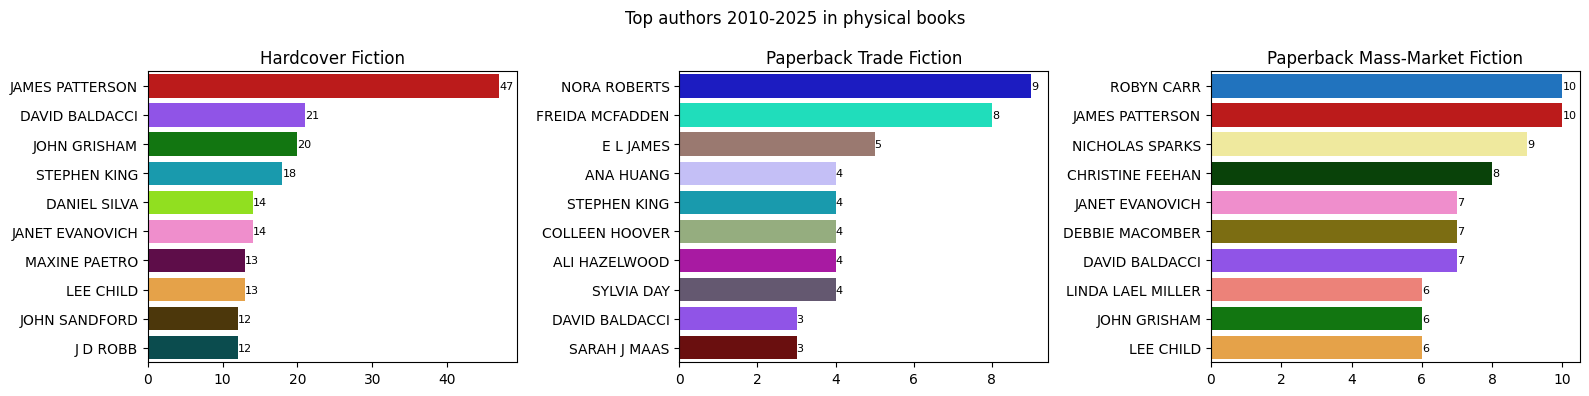

In [11]:
"""
Here we loop through our first 3 results stored (for the first 3 
fiction categories,which are the print categories of fiction: 
Hardcover, Paperback Trade, and Paperback Mass-Market), and create 
a graph bar of the top authors with their respective title counts 
that were ranked 1 on the New York Times Bestseller list.
"""

physical_lists = lists[:3]
fig, axes = plt.subplots(1,3, figsize=(16,4))
fig.suptitle('Top authors 2010-2025 in physical books')
axes = axes.flatten()

for i, list_name in enumerate(physical_lists):
    top_selection = top_authors.loc[
        top_authors['list_name'] == list_name,
        ['author','count']
    ]

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='author',
        hue='author',
        palette=palette,
        ax=axes[i]
    )
    ax.set_title(list_name)
    ax.set(xlabel="",ylabel="")

    for container in ax.containers:
        ax.bar_label(container,fontsize=8)
    
    ax.legend().remove()

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


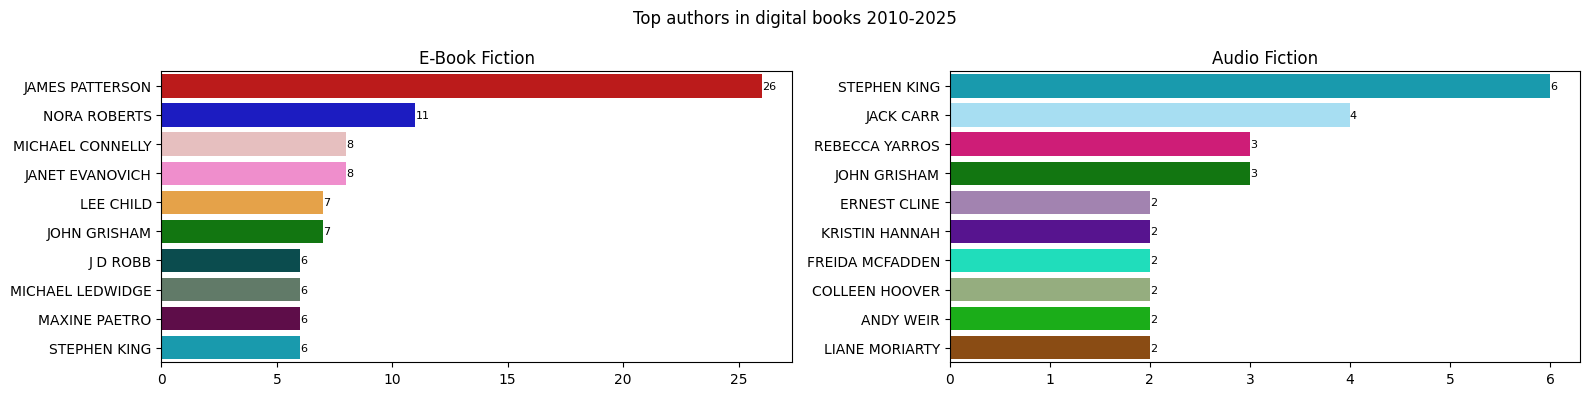

In [12]:
"""
Here we do a similar thing as the graphs above, but for 
the last 2 fiction categories (the digital: E-Book and Audio).
"""
digital_lists = lists[-2:]
fig, axes = plt.subplots(1,2, figsize=(16,4))
fig.suptitle('Top authors in digital books 2010-2025')
axes = axes.flatten()

for i, list_name in enumerate(digital_lists):
    top_selection = top_authors.loc[
        top_authors['list_name'] == list_name,
        ['author','count']
    ]

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='author',
        hue='author',
        palette=palette,
        ax=axes[i]
    )
    ax.set_title(list_name)
    ax.set(xlabel="",ylabel="")

    for container in ax.containers:
        ax.bar_label(container,fontsize=8)
    
    ax.legend().remove()

plt.tight_layout()
plt.show()

### Author's trajectories
In this section, we'll get all the authors with books ranked 1 in fiction categories between 2010-2025, and get the information of the dates, and publishers for later analysis.

In [13]:
# Initialize lists where we'll store queries & results
author_queries = []
author_results = []

for category in lists:
    author_queries.append(
        f"""
        SELECT
            isbn13,
            title,
            author,
            publisher,
            publishing_group,
            date,
            CAST(strftime('%Y', date) AS INTEGER) AS year
        FROM bestsellers
        WHERE
            date BETWEEN '2010-01-01' AND '2026-01-01'
            AND list_name = '{category}'
            AND rank = 1
        """
    )

for query in author_queries:
    author_results.append(pd.read_sql(query,conn))

In [14]:
author_results[1]

,isbn13,title,author,publisher,publishing_group,date,year
0,9780964729230,THE SHACK,WILLIAM P YOUNG,WINDBLOWN MEDIA,OTHER,2010-01-03,2010
1,9780964729230,THE SHACK,WILLIAM P YOUNG,WINDBLOWN MEDIA,OTHER,2010-01-10,2010
2,9780316168816,THE LOVELY BONES,ALICE SEBOLD,BACK BAY,HACHETTE,2010-01-17,2010
3,9780316168816,THE LOVELY BONES,ALICE SEBOLD,BACK BAY,HACHETTE,2010-01-24,2010
4,9781565129771,A RELIABLE WIFE,ROBERT GOOLRICK,ALGONQUIN,HACHETTE,2010-01-31,2010
...,...,...,...,...,...,...,...
822,9781464220845,WILD CARD,ELSIE SILVER,BLOOM,OTHER,2025-09-28,2025
823,9780008728090,THE GINGERBREAD BAKERY,LAURIE GILMORE,HARPERCOLLINS,HARPERCOLLINS,2025-10-05,2025
824,9781538742570,THE HOUSEMAID,FREIDA MCFADDEN,GRAND CENTRAL,HACHETTE,2025-10-12,2025
825,9780593977774,SOUL SEARCHING,LYLA SAGE,DIAL,PENGUIN RANDOM HOUSE,2025-10-19,2025


In [15]:
"""
Here we filter the results stored in `author_results`, to only have the
data of the top authors we obtained in the previous section (the `top_authors_dictionary`
where we have a list of the top authors for each Fiction category).
"""
counter = 0
filtered_author_results = []
for res in author_results:
    authors = top_authors_dictionary[lists[counter]]
    filtered_author_results.append(
        res[res['author'].isin(authors)]
    )
    counter += 1

In [ ]:
"""
Here we create dataframes of the number of times each author
(from the top authors) has a book in rank #1 for each year, so we
can later create a heatmap with the information.

The dataframes have the following format:
| year         | 2010 | 2011 | 2012 | ... | 2025 |
|--------------|------|------|------|-----|------|
| author       |      |      |      |     |      |
| DANIEL SILVA | 1    | 0    | 1    | ... | 1    |
| ...          | ...  | ...  | ...  | ... | ...  |
| STEPHEN KING | 0    | 2    | 3    | ... | 1    |
"""
heatmap_dfs = []
for res in filtered_author_results:
  heatmap_df = (
    res.groupby(["author", "year"])
    .size()
    .unstack(fill_value=0)
  )
  heatmap_dfs.append(heatmap_df)

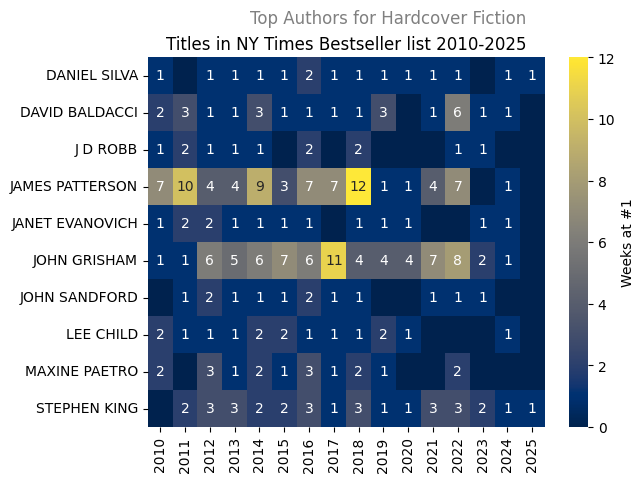

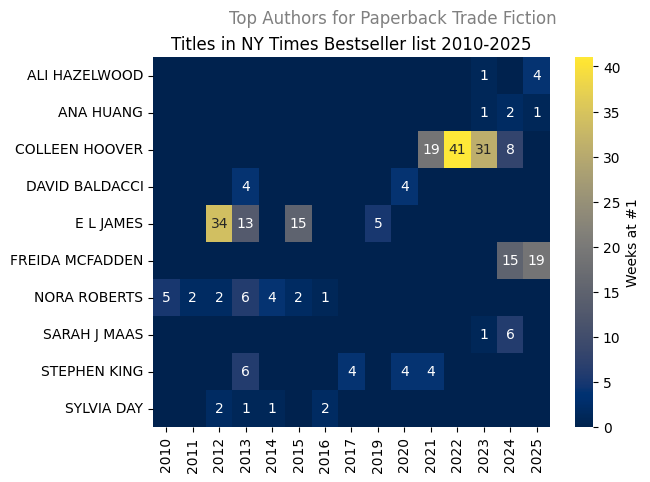

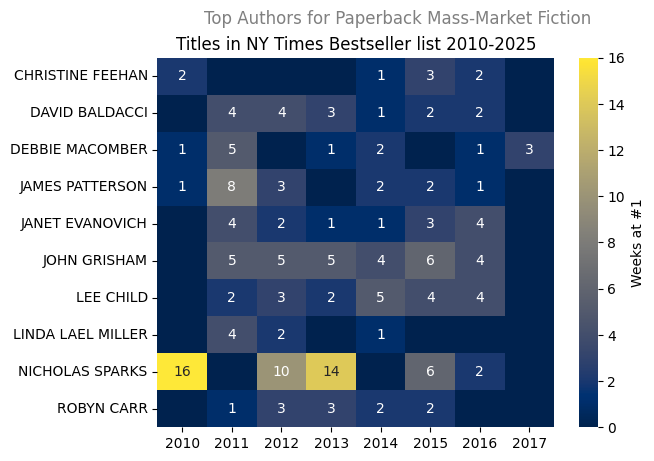

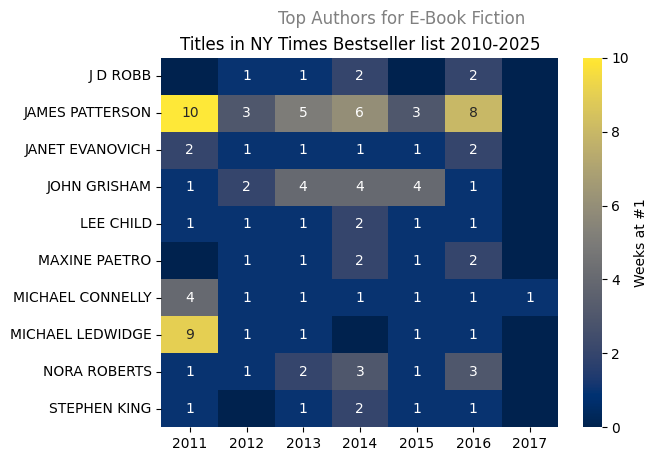

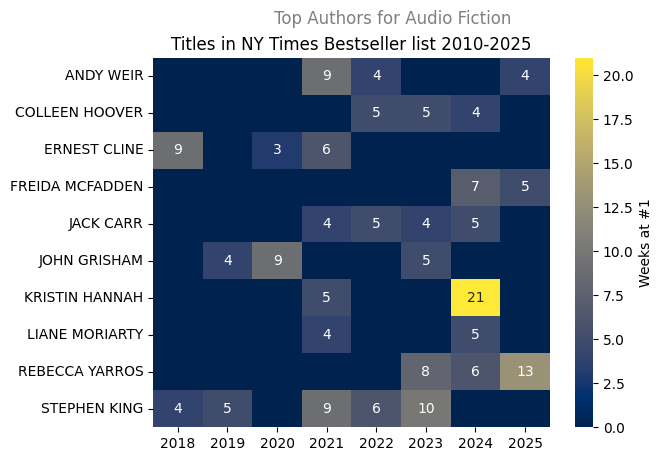

In [18]:
"""
Here we create a heatmap for each fiction category with its top authors,
and the number of weeks each author had a book ranked #1 in the New York
Times Bestseller list for each of the Fiction categories.
"""
counter = 0
for heatmap in heatmap_dfs:
    # Create annotation matrix to not show 0 in the heatmap
    annot_matrix = heatmap.applymap(lambda x: '' if x == 0 else x)

    # Create heatmap of the top authors
    ax = sns.heatmap(heatmap, 
                cmap='cividis', annot=annot_matrix, 
                fmt="", cbar_kws={'label':'Weeks at #1'})
    ax.set(xlabel="", ylabel="")
    plt.title('Titles in NY Times Bestseller list 2010-2025')
    plt.suptitle(f'Top Authors for {lists[counter]}', color='grey')
    plt.show()
    counter += 1

### Publishers
In this section we'll first get the counts for how many titles ranked 1 for each publishing group in each fiction category. Then, we'll get for each of the "Big 5" publishing groups get their top imprints for each fiction category.

#### Publishing Groups

In [19]:
"""
In this section, we'll get all publishing groups that 
got books into rank #1 between 2010 and 2025.
"""

# Initialize lists where we'll store queries & results
pub_group_queries = []
pub_group_results = []

for category in lists:
    pub_group_queries.append(
        f"""
        SELECT
            DISTINCT isbn13,
            publishing_group
        FROM bestsellers
        WHERE
            date BETWEEN '2010-01-01' AND '2026-01-01'
            AND list_name = '{category}'
            AND rank = 1
        """
    )

for query in pub_group_queries:
    pub_group_results.append(pd.read_sql(query,conn))

In [ ]:
"""
For each resulting dataframe in `pub_group_results`,
count each distinct publishing group, making a new dataframe
with the counts, and the name of the category 
(`list_name`). Then, store the results in a new
dataframe `pub_group_df`.
The resulting dataframe `pub_group_df` has the format:
| publishing_group | count | listname          |
|------------------|-------|-------------------|
| BLOOMSBURY       | 4     | Hardcover Fiction |
| ...              | ...   | ...               |
| SIMON & SCHUSTER | 13    | Audio Fiction     |
"""
pub_group_df = pd.DataFrame()
for i, res in enumerate(pub_group_results):
    grouped = (
        res.groupby("publishing_group")
        .size()
        .reset_index(name="count")
    )

    grouped["list_name"] = lists[i]

    pub_group_df = pd.concat([pub_group_df, grouped], ignore_index=True)

In [22]:
# Check the top 10 of publishing groups for each fiction category
top_pub_group = pub_group_df.sort_values(by='count', ascending=False).groupby('list_name').head(10)

In [24]:
all_pub_groups = top_pub_group['publishing_group'].unique()

palette = dict(zip(
    all_pub_groups,
    sns.color_palette("tab10") 
))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


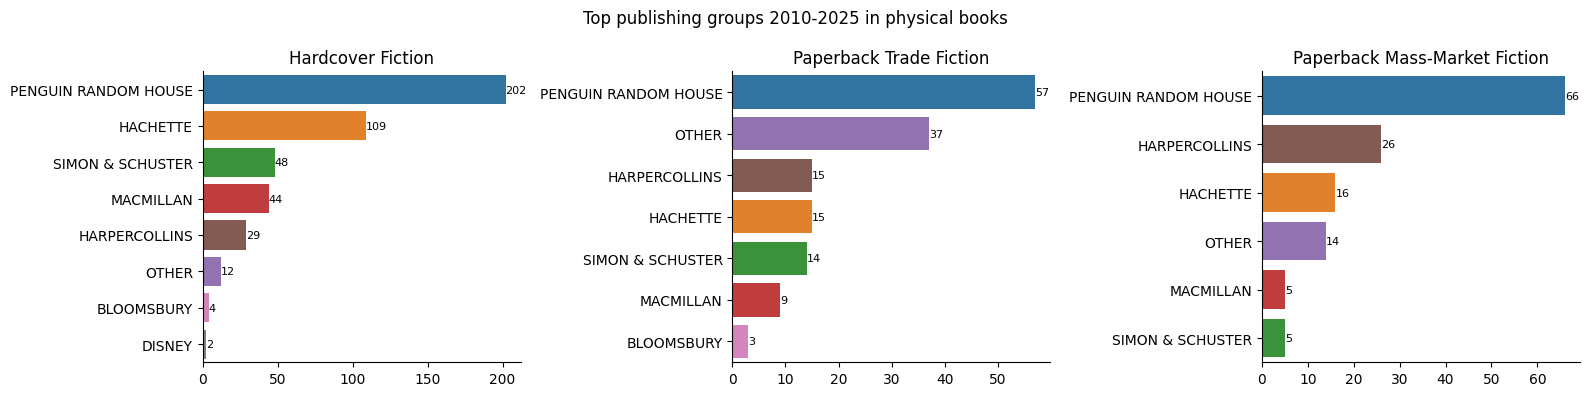

In [ ]:
"""
Here we plot the publishing group counts of titles ranked 1 
in the list between 2010-2025, for the print fiction categories
(Hardcover, Paperback Trade, and Paperback Mass-Market).
"""

physical_lists = lists[:3]
fig, axes = plt.subplots(1,3, figsize=(16,4))
fig.suptitle('Top publishing groups 2010-2025 in physical books')
axes = axes.flatten()

for i, list_name in enumerate(physical_lists):
    top_selection = top_pub_group.loc[
        top_pub_group['list_name'] == list_name,
        ['publishing_group','count']
    ].sort_values('count', ascending=False)

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publishing_group',
        hue='publishing_group',
        palette=palette,
        ax=axes[i]
    )
    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="",ylabel="")

    for container in ax.containers:
        ax.bar_label(container,fontsize=8)
    
    ax.legend().remove()

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


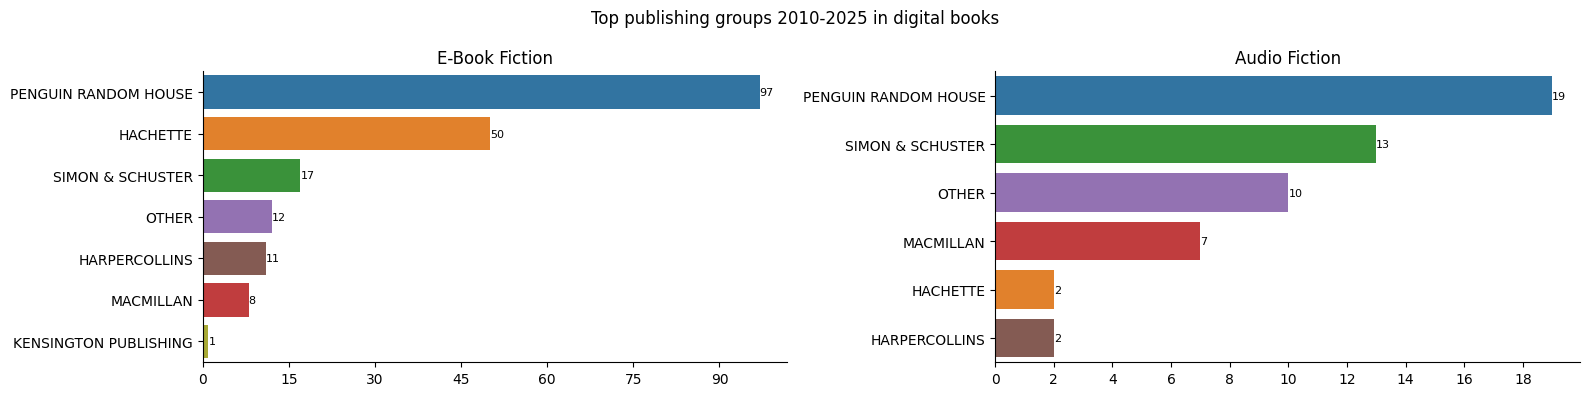

In [ ]:
"""
Here we plot the same as before, but for the digital fiction 
categories (E-Book and Audio).
"""

digital_lists = lists[-2:]
fig, axes = plt.subplots(1,2, figsize=(16,4))
fig.suptitle('Top publishing groups 2010-2025 in digital books')
axes = axes.flatten()

for i, list_name in enumerate(digital_lists):
    top_selection = top_pub_group.loc[
        top_pub_group['list_name'] == list_name,
        ['publishing_group','count']
    ].sort_values('count', ascending=False)

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publishing_group',
        hue='publishing_group',
        palette=palette,
        ax=axes[i]
    )
    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="",ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    for container in ax.containers:
        ax.bar_label(container,fontsize=8)
    
    ax.legend().remove()

plt.tight_layout()
plt.show()

#### Top publishers from each publishing group

##### Big 5 Publishers
In this section we obtain the counts for each imprint from the Big 5 publishing groups (Penguin Random House, Hachette, HarperCollins, Macmillan, and Simon & Schuster) that got titles ranked #1 in the New York Times Bestseller list between 2010-2025.

In [ ]:
"""
Here we obtain a dataframe from querying our data, 
selecting the publisher (imprint), publishing group, list_name 
and the count of each distinct book that got ranked 1 
on the list between 2010-2025 that is part of one of the 
big 5 publishers in each Fiction category.
"""
big_five_df = (
    pd.read_sql("""
            SELECT
                publisher,
                publishing_group,
                list_name,
                COUNT(DISTINCT isbn13) AS count
            FROM bestsellers
            WHERE
                date BETWEEN '2010-01-01' AND '2026-01-01'
                AND rank = 1
                AND publishing_group IN (
                    'PENGUIN RANDOM HOUSE',
                    'HACHETTE',
                    'HARPERCOLLINS',
                    'MACMILLAN',
                    'SIMON & SCHUSTER'
                )
                AND list_name IN (
                    'Hardcover Fiction',
                    'Paperback Trade Fiction',
                    'Paperback Mass-Market Fiction',
                    'E-Book Fiction',
                    'Audio Fiction'
                )
            GROUP BY
                publisher,
                publishing_group,
                list_name
            ORDER BY
                list_name,
                count DESC;
            """,
            conn)
)


In [43]:
big_five_df.groupby('list_name').head(10)

,publisher,publishing_group,list_name,count
0,SIMON & SCHUSTER AUDIO,SIMON & SCHUSTER,Audio Fiction,12
1,RANDOM HOUSE AUDIO,PENGUIN RANDOM HOUSE,Audio Fiction,10
2,MACMILLAN AUDIO,MACMILLAN,Audio Fiction,7
3,PENGUIN AUDIO,PENGUIN RANDOM HOUSE,Audio Fiction,5
4,HACHETTE AUDIO,HACHETTE,Audio Fiction,2
5,HARPERAUDIO,HARPERCOLLINS,Audio Fiction,2
6,ATRIA,SIMON & SCHUSTER,Audio Fiction,1
7,BALLANTINE,PENGUIN RANDOM HOUSE,Audio Fiction,1
8,DOUBLEDAY,PENGUIN RANDOM HOUSE,Audio Fiction,1
9,NAN A TALESE,PENGUIN RANDOM HOUSE,Audio Fiction,1


In [ ]:
"""
Here we create a dataframe for each of the 5 big publishing groups
with their respective top 10 imprints for each fiction category.
"""
penguin_df = (
    big_five_df[big_five_df['publishing_group'] == 'PENGUIN RANDOM HOUSE']
    .groupby('list_name').head(10)
)

simon_schuster_df = (
    big_five_df[big_five_df['publishing_group'] == 'SIMON & SCHUSTER']
    .groupby('list_name').head(10)
)

hachette_df = (
    big_five_df[big_five_df['publishing_group'] == 'HACHETTE']
    .groupby('list_name').head(10)
)

macmillan_df = (
    big_five_df[big_five_df['publishing_group'] == 'MACMILLAN']
    .groupby('list_name').head(10)
)

harpercollins_df = (
    big_five_df[big_five_df['publishing_group'] == 'HARPERCOLLINS']
    .groupby('list_name').head(10)
)

##### Penguin Random House
In this section we plot the top Penguin Random House imprints for each fiction category.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0.98, 'Top Imprints in Digital Books, 2010-2025')

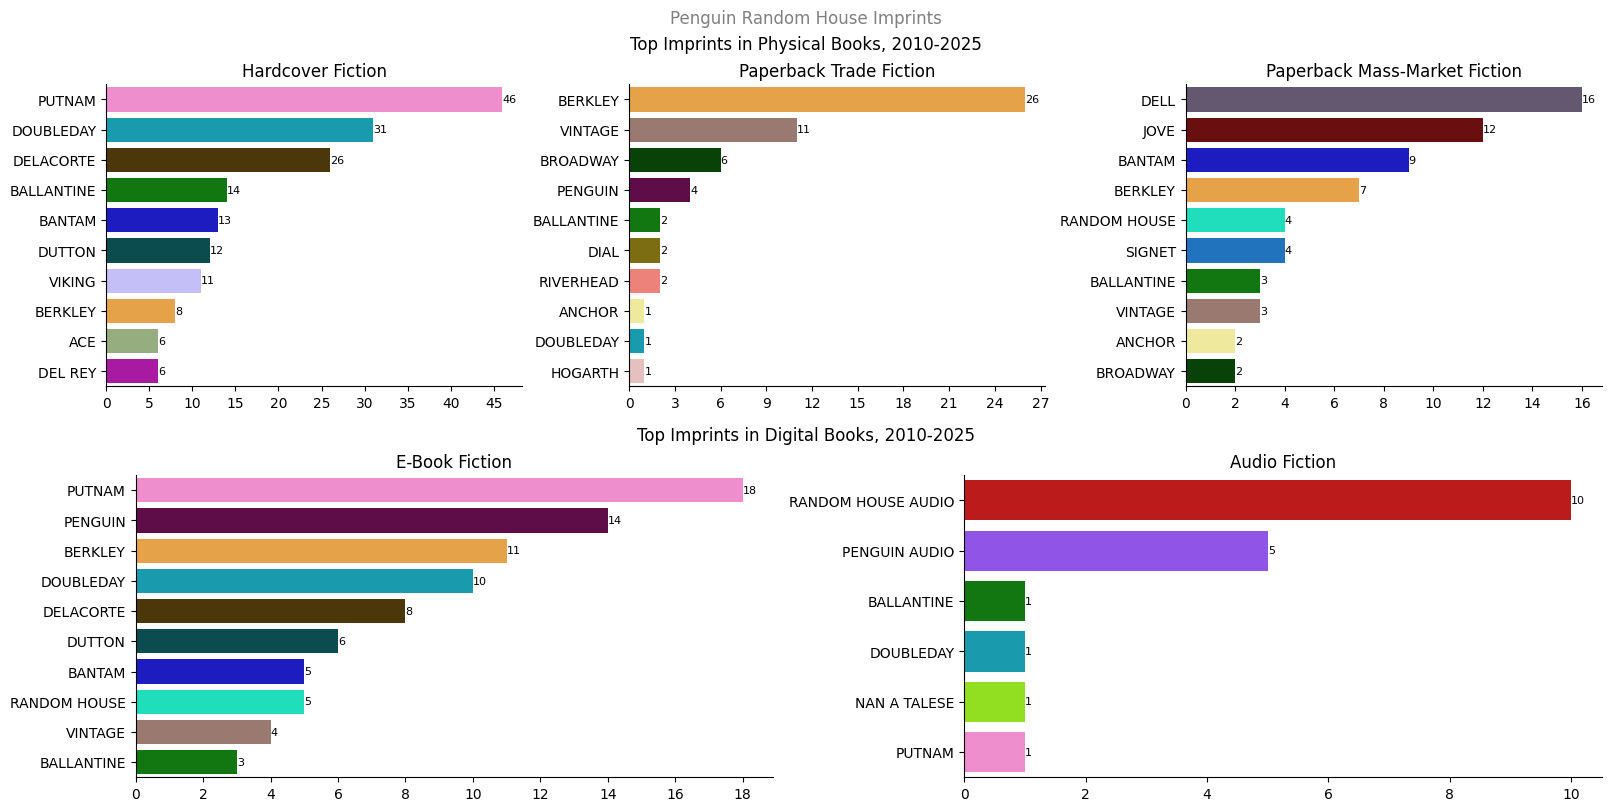

In [36]:
# Create a color palette with a unique color for each Penguin Random House imprint
prh_imprints = penguin_df['publisher'].unique()

# The cc.glasbey helps creating a color palette of 30+ colors
# more colorblind-friendly
palette = dict(zip(
    prh_imprints,
    sns.color_palette(cc.glasbey, 31) 
))

top_lists = lists[:3]
bottom_lists = lists[3:]

fig = plt.figure(figsize=(16,8),constrained_layout=True)
fig.suptitle('Penguin Random House Imprints', color='grey')     

subfig_top, subfig_bottom = fig.subfigures(2, 1)
axes_top = subfig_top.subplots(1, 3)
axes_bottom = subfig_bottom.subplots(1, 2)

# Top Row of Graphs
for i, list_name in enumerate(top_lists):

    top_selection = (
        penguin_df[
            penguin_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_top[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

# Bottom Row of Graphs
for i, list_name in enumerate(bottom_lists):

    top_selection = (
        penguin_df[
            penguin_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_bottom[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

subfig_top.suptitle('Top Imprints in Physical Books, 2010-2025')               
subfig_bottom.suptitle('Top Imprints in Digital Books, 2010-2025')   

#### Simon & Schuster
In this section we plot the top Simon & Schuster imprints for each fiction category.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0.98, 'Top Imprints in Digital Books, 2010-2025')

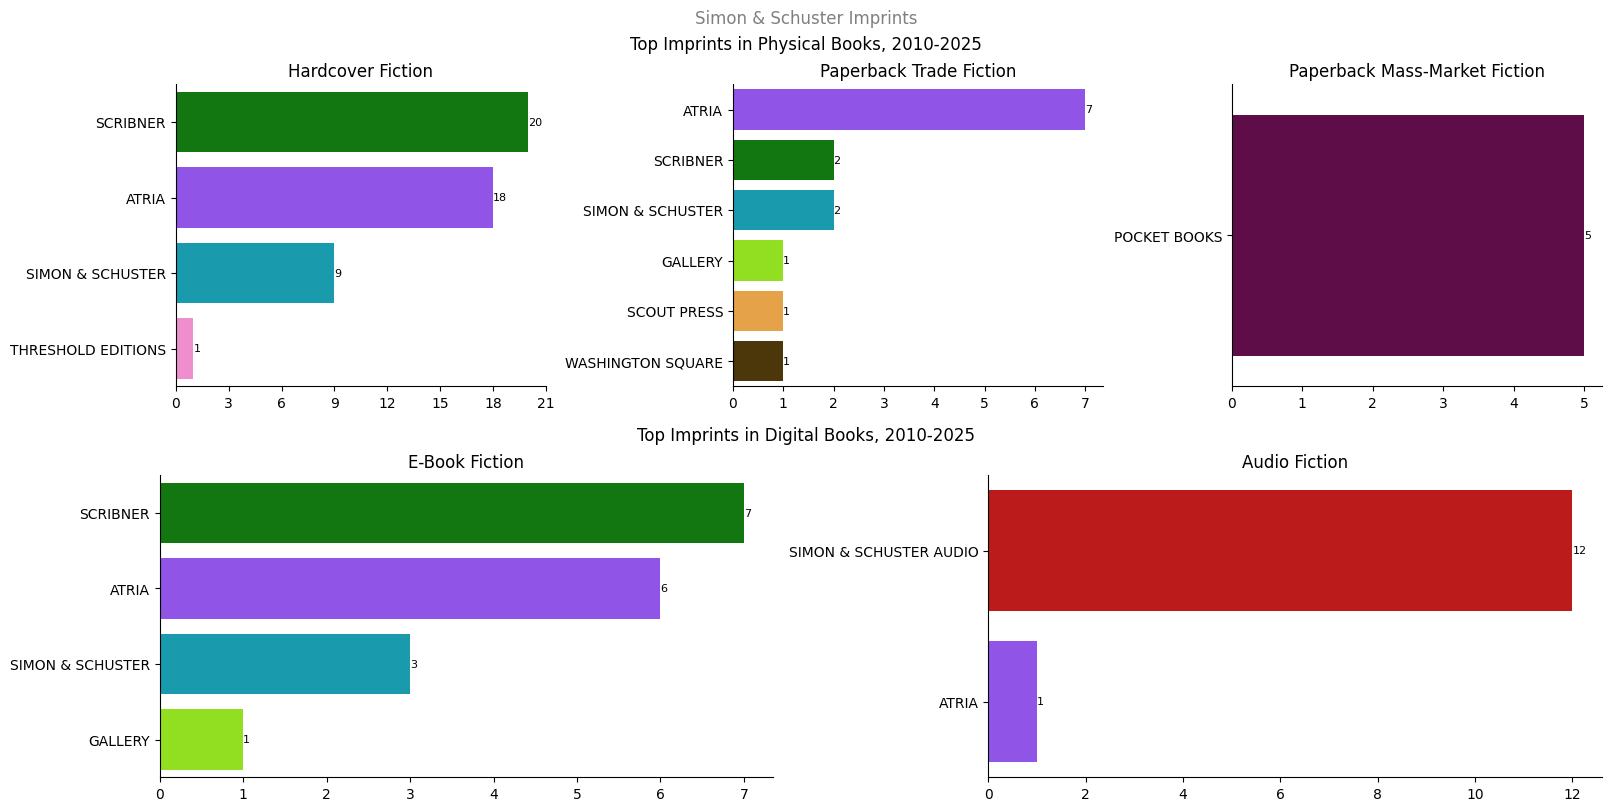

In [37]:
# Create a color palette with a unique color for each Simon & Schuster imprint
simon_schuster_imprints = simon_schuster_df['publisher'].unique()

# The cc.glasbey helps creating a color palette of 30+ colors
# more colorblind-friendly
palette = dict(zip(
    simon_schuster_imprints,
    sns.color_palette(cc.glasbey, 31) 
))

top_lists = lists[:3]
bottom_lists = lists[3:]

fig = plt.figure(figsize=(16,8),constrained_layout=True)
fig.suptitle('Simon & Schuster Imprints', color='grey')     

subfig_top, subfig_bottom = fig.subfigures(2, 1)
axes_top = subfig_top.subplots(1, 3)
axes_bottom = subfig_bottom.subplots(1, 2)

# Top Row of Graphs
for i, list_name in enumerate(top_lists):

    top_selection = (
        simon_schuster_df[
            simon_schuster_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_top[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

# Bottom Row of Graphs
for i, list_name in enumerate(bottom_lists):

    top_selection = (
        simon_schuster_df[
            simon_schuster_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_bottom[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

subfig_top.suptitle('Top Imprints in Physical Books, 2010-2025')               
subfig_bottom.suptitle('Top Imprints in Digital Books, 2010-2025')   

#### Hachette
In this section we plot the top Hachette imprints for each fiction category.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0.98, 'Top Imprints in Digital Books, 2010-2025')

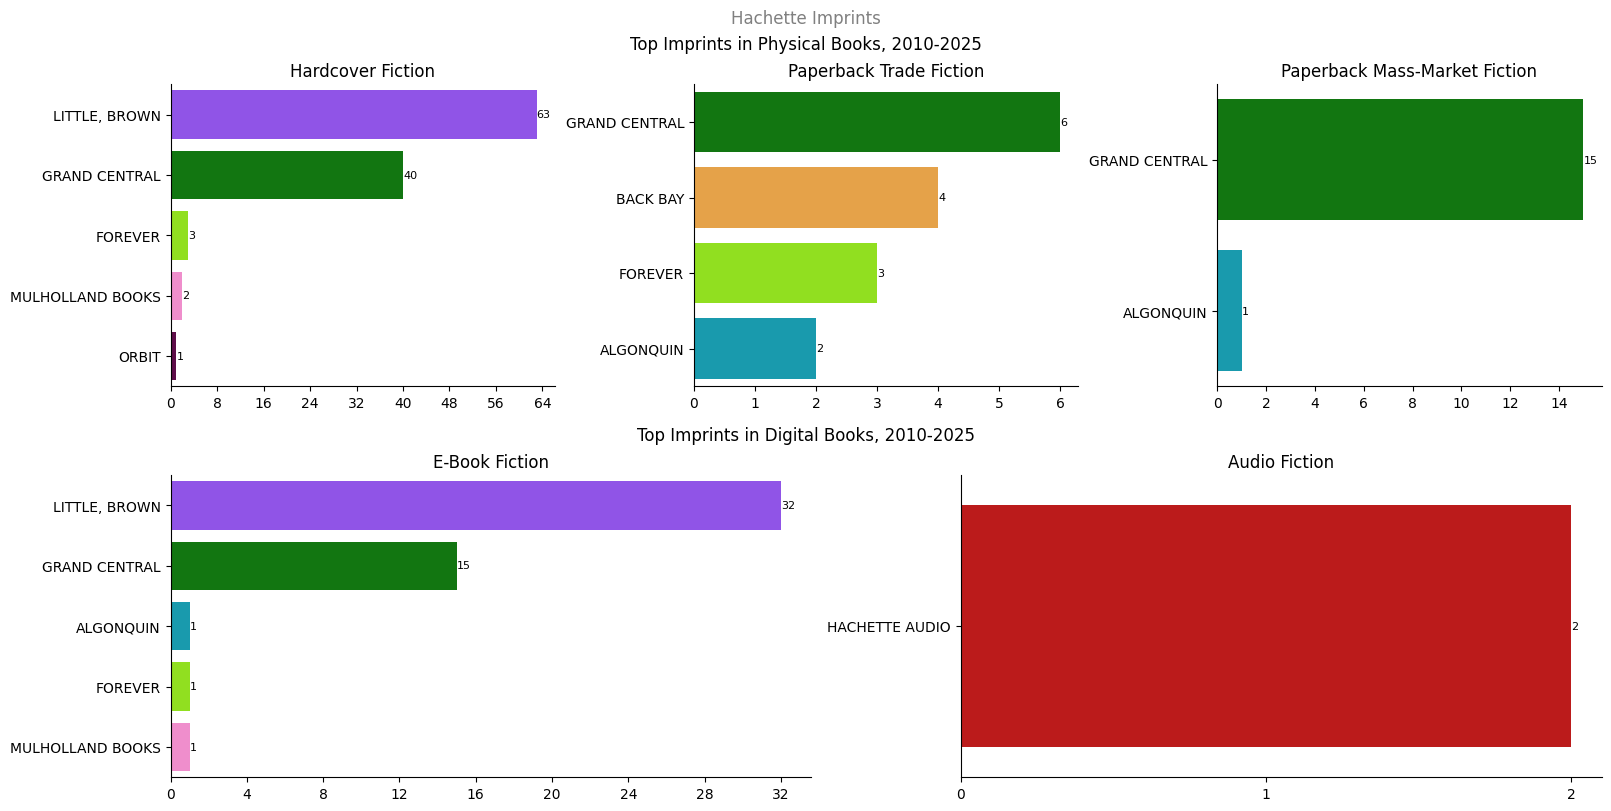

In [38]:
# Create a color palette with a unique color for each Hachette imprint
hachette_imprints = hachette_df['publisher'].unique()

# The cc.glasbey helps creating a color palette of 30+ colors
# more colorblind-friendly
palette = dict(zip(
    hachette_imprints,
    sns.color_palette(cc.glasbey, 31) 
))

top_lists = lists[:3]
bottom_lists = lists[3:]

fig = plt.figure(figsize=(16,8),constrained_layout=True)
fig.suptitle('Hachette Imprints', color='grey')     

subfig_top, subfig_bottom = fig.subfigures(2, 1)
axes_top = subfig_top.subplots(1, 3)
axes_bottom = subfig_bottom.subplots(1, 2)

# Top Row of Graphs
for i, list_name in enumerate(top_lists):

    top_selection = (
        hachette_df[
            hachette_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_top[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

# Bottom Row of Graphs
for i, list_name in enumerate(bottom_lists):

    top_selection = (
        hachette_df[
            hachette_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_bottom[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

subfig_top.suptitle('Top Imprints in Physical Books, 2010-2025')               
subfig_bottom.suptitle('Top Imprints in Digital Books, 2010-2025')   

#### Macmillan
In this section we plot the top Macmillan imprints for each fiction category.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0.98, 'Top Imprints in Digital Books, 2010-2025')

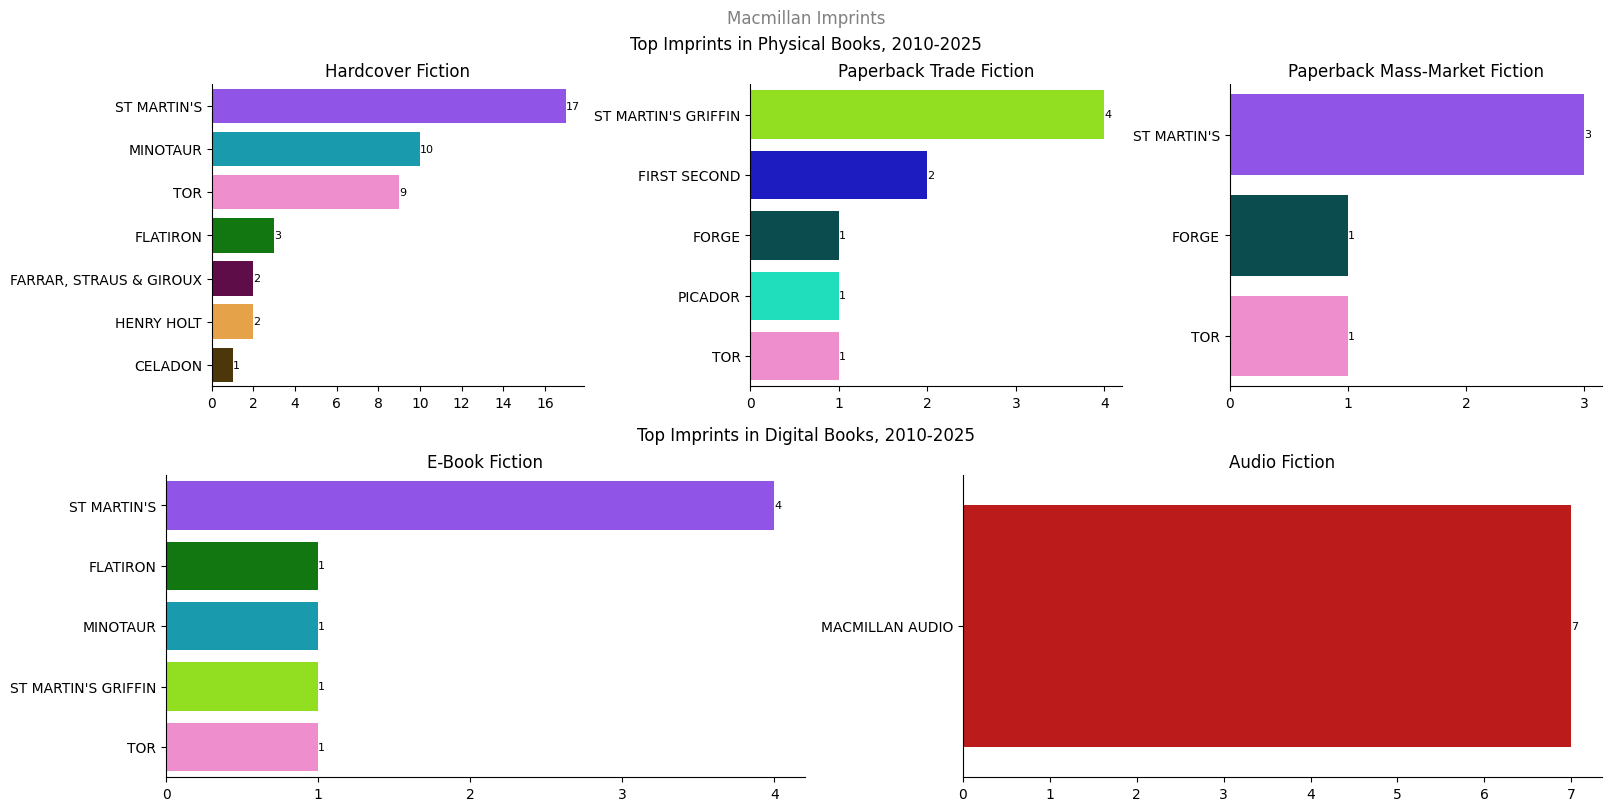

In [39]:
# Create a color palette with a unique color for each Macmillan imprint
macmillan_imprints = macmillan_df['publisher'].unique()

# The cc.glasbey helps creating a color palette of 30+ colors
# more colorblind-friendly
palette = dict(zip(
    macmillan_imprints,
    sns.color_palette(cc.glasbey, 31) 
))

top_lists = lists[:3]
bottom_lists = lists[3:]

fig = plt.figure(figsize=(16,8),constrained_layout=True)
fig.suptitle('Macmillan Imprints', color='grey')     

subfig_top, subfig_bottom = fig.subfigures(2, 1)
axes_top = subfig_top.subplots(1, 3)
axes_bottom = subfig_bottom.subplots(1, 2)

# Top Row of Graphs
for i, list_name in enumerate(top_lists):

    top_selection = (
        macmillan_df[
            macmillan_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_top[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

# Bottom Row of Graphs
for i, list_name in enumerate(bottom_lists):

    top_selection = (
        macmillan_df[
            macmillan_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_bottom[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

subfig_top.suptitle('Top Imprints in Physical Books, 2010-2025')               
subfig_bottom.suptitle('Top Imprints in Digital Books, 2010-2025')   

#### HarperCollins
In this section we plot the top HarperCollins imprints for each fiction category. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0.98, 'Top Imprints in Digital Books, 2010-2025')

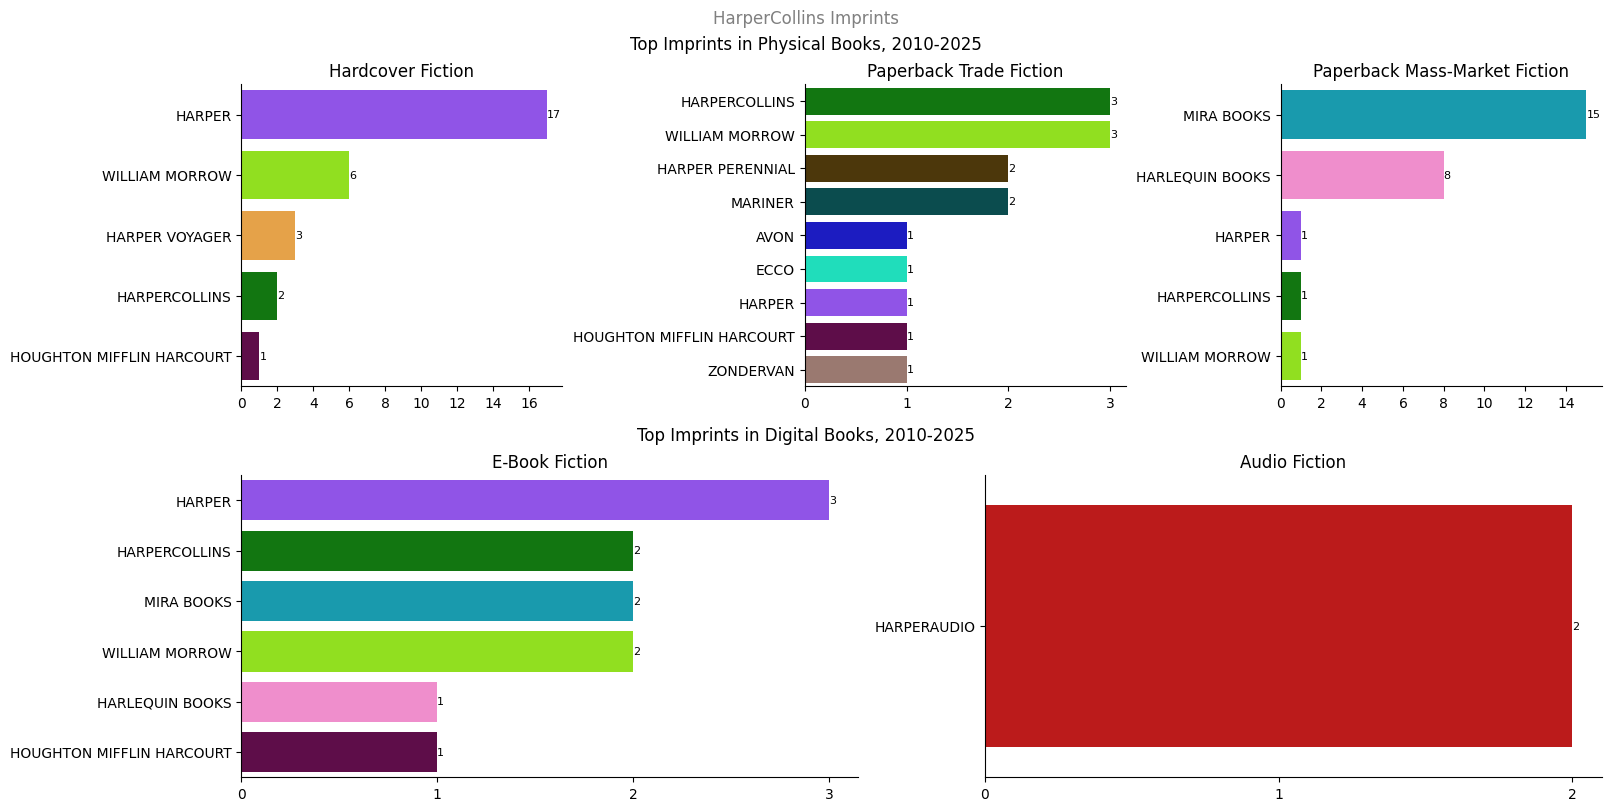

In [40]:
# Create a color palette with a unique color for each HarperCollins imprint
harpercollins_imprints = harpercollins_df['publisher'].unique()

# The cc.glasbey helps creating a color palette of 30+ colors
# more colorblind-friendly
palette = dict(zip(
    harpercollins_imprints,
    sns.color_palette(cc.glasbey, 31) 
))

top_lists = lists[:3]
bottom_lists = lists[3:]

fig = plt.figure(figsize=(16,8),constrained_layout=True)
fig.suptitle('HarperCollins Imprints', color='grey')     

subfig_top, subfig_bottom = fig.subfigures(2, 1)
axes_top = subfig_top.subplots(1, 3)
axes_bottom = subfig_bottom.subplots(1, 2)

# Top Row of Graphs
for i, list_name in enumerate(top_lists):

    top_selection = (
        harpercollins_df[
            harpercollins_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_top[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

# Bottom Row of Graphs
for i, list_name in enumerate(bottom_lists):

    top_selection = (
        harpercollins_df[
            harpercollins_df['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        palette=palette,
        ax=axes_bottom[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend().remove()

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

subfig_top.suptitle('Top Imprints in Physical Books, 2010-2025')               
subfig_bottom.suptitle('Top Imprints in Digital Books, 2010-2025')   

##### Top Imprints (General)

In [45]:
"""
Here we obtain a dataframe from querying our data, 
selecting the publisher (imprint), publishing group, list_name 
and the count of each distinct book that got ranked 1 
on the list between 2010-2025 in each Fiction category.
"""
publishers_df = (
    pd.read_sql("""
            SELECT
                publisher,
                publishing_group,
                list_name,
                COUNT(DISTINCT isbn13) AS count
            FROM bestsellers
            WHERE
                date BETWEEN '2010-01-01' AND '2026-01-01'
                AND rank = 1
                AND list_name IN (
                    'Hardcover Fiction',
                    'Paperback Trade Fiction',
                    'Paperback Mass-Market Fiction',
                    'E-Book Fiction',
                    'Audio Fiction'
                )
            GROUP BY
                publisher,
                publishing_group,
                list_name
            ORDER BY
                list_name,
                count DESC;
            """,
            conn)
)


In [ ]:
# Here, we get the top 10 imprints for each fiction category
top_publishers = publishers_df.groupby('list_name').head(10)

In [ ]:
# Store the unique publishing groups
publishing_groups = top_publishers['publishing_group'].unique()

In [ ]:
# Create a color palette for the publishing groups
pub_group_palette = dict(zip(
    publishing_groups,
    sns.color_palette("colorblind") 
))

In [ ]:
# Assign the color to the imprints according to the color assigned to 
# their publishing group
imprints_palette = {}
for row in top_publishers[['publisher', 'publishing_group']].itertuples(index=False):
    imprints_palette[row.publisher] = pub_group_palette[row.publishing_group] 

Text(0.5, 0.98, 'Top Imprints in Digital Books, 2010-2025')

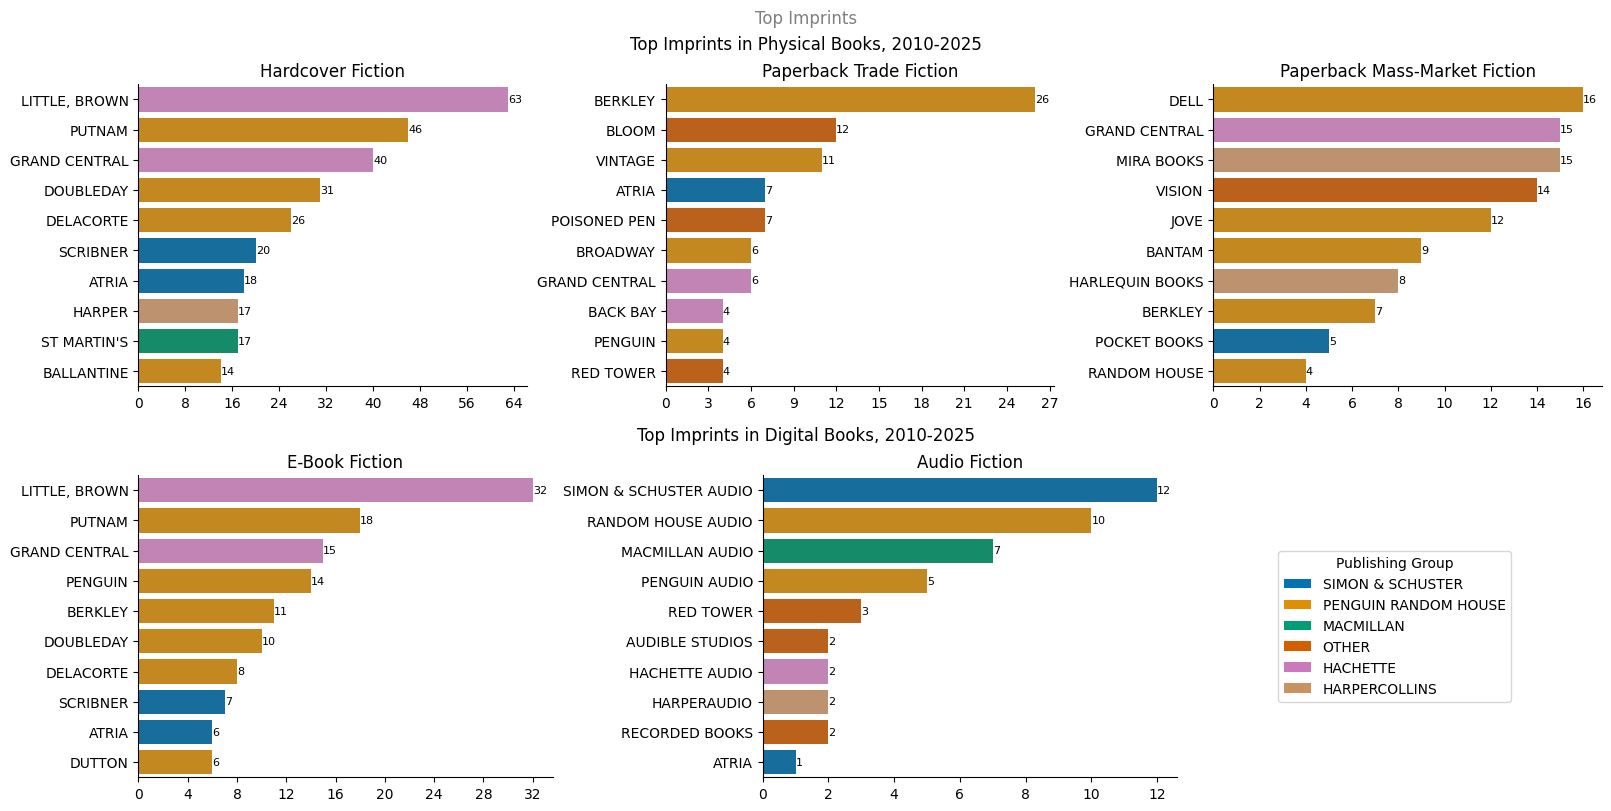

In [ ]:
# Plot the top imprints for the Fiction categories
top_lists = lists[:3]
bottom_lists = lists[3:]

fig = plt.figure(figsize=(16,8),constrained_layout=True)
fig.suptitle('Top Imprints', color='grey')     

subfig_top, subfig_bottom = fig.subfigures(2, 1)
axes_top = subfig_top.subplots(1, 3)
axes_bottom = subfig_bottom.subplots(1, 3)

# Top Row of Graphs
for i, list_name in enumerate(top_lists):

    top_selection = (
        top_publishers[
            top_publishers['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        legend=False,
        palette=imprints_palette,
        ax=axes_top[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

# Bottom Row of Graphs
for i, list_name in enumerate(bottom_lists):

    top_selection = (
        top_publishers[
            top_publishers['list_name'] == list_name
        ][['publisher', 'count']]
        .sort_values('count', ascending=False)
    )

    ax = sns.barplot(
        data=top_selection,
        x='count',
        y='publisher',
        hue='publisher',
        legend=False,
        palette=imprints_palette,
        ax=axes_bottom[i]
    )

    sns.despine()
    ax.set_title(list_name)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

axes_bottom[2].axis('off')

# Adding the legend on the bottom right corner with the publishing
# groups color palette
legend_elements = [
    Patch(facecolor=color, label=group)
    for group, color in pub_group_palette.items()
]

axes_bottom[2].legend(
    handles=legend_elements,
    title='Publishing Group',
    loc='center'
)

subfig_top.suptitle('Top Imprints in Physical Books, 2010-2025')               
subfig_bottom.suptitle('Top Imprints in Digital Books, 2010-2025')